In [1]:
import sys
sys.path.append('../src/')
from fluProfiler_models import fluProfiler_Config, fluProfiler_HANA
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
import json
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
from utilities import load_embedding, EarlyStopping
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datetime import datetime
import pickle
from utilities import print_exams
import matplotlib.pyplot as plt

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

def draw_compare_bar(tools, mae, save_path):
    # 新建图表
    plt.figure(figsize=(4, 2.8), dpi=300)
    # 配色（简洁高对比，常见于 Science 等期刊）
    colors = ["#4c78a8", "#f58518", "#54a24b"]
    # 画柱状图
    bars = plt.bar(tools, mae, color=colors, width=0.6, label=tools)

    # 去掉上和右边框，更简洁
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 设置标签和刻度
    plt.ylabel("HI titer prediction error", fontsize=8)

    # 在柱子上标数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f"{height:.2f}", ha='center', va='bottom', fontsize=7)


    # 紧凑布局
    plt.legend(tools, fontsize=8, frameon=False)
    plt.tight_layout()

    plt.xticks(size=7)
    plt.yticks(size=7)

    # 显示图
    plt.savefig(save_path, format="svg", transparent=True, bbox_inches="tight")


In [ ]:
fluProfiler_titer = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/fluProfiler_titer.csv', index_col=False)
Nextflu_titer = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Nextflu_titer.csv', index_col=False)
Adaboost_titer = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Adaboost_titer.csv', index_col=False)

fluProfiler_strain = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/fluProfiler_strain.csv', index_col=False)
Nextflu_strain = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Nextflu_strain.csv', index_col=False)
Adaboost_strain = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Adaboost_strain.csv', index_col=False)

fluProfiler_serum = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/fluProfiler_serum.csv', index_col=False)
Nextflu_serum = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Nextflu_serum.csv', index_col=False)
Adaboost_serum = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Adaboost_serum.csv', index_col=False)

fluProfiler_41 = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/fluProfiler_41.csv', index_col=False)
Nextflu_41 = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Nextflu_41.csv', index_col=False)
Adaboost_41 = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Adaboost_41.csv', index_col=False)

fluProfiler_CDC = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/fluProfiler_CDC.csv', index_col=False)
Nextflu_CDC = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Nextflu_CDC.csv', index_col=False)
Adaboost_CDC = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Adaboost_CDC.csv', index_col=False)

fluProfiler_CNIC = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/fluProfiler_CNIC.csv', index_col=False)
Nextflu_CNIC = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Nextflu_CNIC.csv', index_col=False)
Adaboost_CNIC = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/Figure/Fig2/Adaboost_CNIC.csv', index_col=False)

In [5]:
Crick_all = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler/data/data_40/all.csv', index_col=False)

In [6]:
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Crick_all.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Crick_data_final = Crick_all.groupby(group_columns).agg(agg_dict).reset_index()

In [7]:
def assign_season(date):
    # if less than 31st January, then NH season
    if date[5:] <= "01-31":
        return date[:4] + "NH"
    # if between 1st February and 31st August, then SH
    elif (date[5:] >= "02-01") and (date[5:] <= "08-31"):
        return date[:4] + "SH"
    # if between 1st September and 31st December, then next year's NH
    elif (date[5:] >= "09-01") and (date[5:] <= "12-31"):
        season_year = int(date[:4])
        return str(season_year+1) + "NH"
    else:
        return None

def DF_standardize_date(data):
    '''
    turn character date
    '''
    # turn character date to datetime date
    data['serumDate'] = pd.to_datetime(
        data['serumDate'], format='%Y-%m-%d', errors='coerce')
    data['virusDate'] = pd.to_datetime(
        data['virusDate'], format='%Y-%m-%d', errors='coerce')

    try:
        data['serumDate'] = data['serumDate'].dt.strftime('%Y-%m-%d')
    except:
        date = data['serumDate'].dt.strftime('%Y-%m')
        date.replace(day=1)
        data['serumDate'] = date

    try:
        data['virusDate'] = data['virusDate'].dt.strftime('%Y-%m-%d')
    except:
        date = data['virusDate'].dt.strftime('%Y-%m')
        date.replace(day=1)
        data['virusDate'] = date

    # remove record without date
    data = data.dropna(subset=['virusDate'])

    return data


In [8]:
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in fluProfiler_CDC.columns if c not in group_columns}
agg_dict['label'] = 'mean'
fluProfiler_CDC_final = fluProfiler_CDC.groupby(group_columns).agg(agg_dict).reset_index()

### 2A titer

In [9]:
def to_concat_df(s_1, s_2, s_3):
    df_1 = s_1.to_frame()
    df_1['model'] = 'fluProfiler'
    df_1.columns = ['value', 'model']   
    df_2 = s_2.to_frame()
    df_2['model'] = 'Nextflu'
    df_2.columns = ['value', 'model']
    df_3 = s_3.to_frame()
    df_3['model'] = 'Adaboost'
    df_3.columns = ['value', 'model']
    
    df = pd.concat([df_1, df_2, df_3], axis=0)
    return df


In [10]:
fluProfiler_titer_error = abs(fluProfiler_titer['label'] - fluProfiler_titer['prediction'])
Nextflu_titer_error = abs(Nextflu_titer['label'] - Nextflu_titer['pred_without_name'])
Adaboost_titer_error = abs(Adaboost_titer['label'] - Adaboost_titer['pred_without_name'])

fluProfiler_strain_error = abs(fluProfiler_strain['label'] - fluProfiler_strain['prediction'])
Nextflu_strain_error = abs(Nextflu_strain['label'] - Nextflu_strain['pred_without_name'])
Adaboost_strain_error = abs(Adaboost_strain['label'] - Adaboost_strain['pred_without_name'])

fluProfiler_serum_error = abs(fluProfiler_serum['label'] - fluProfiler_serum['prediction'])
Nextflu_serum_error = abs(Nextflu_serum['label'] - Nextflu_serum['pred_without_name'])
Adaboost_serum_error = abs(Adaboost_serum['label'] - Adaboost_serum['pred_without_name'])

fluProfiler_41_error = abs(fluProfiler_41['label'] - fluProfiler_41['prediction'])
Nextflu_41_error = abs(Nextflu_41['label'] - Nextflu_41['pred_without_name'])
Adaboost_41_error = abs(Adaboost_41['label'] - Adaboost_41['pred_without_name'])

fluProfiler_CDC_error = abs(fluProfiler_CDC['label'] - fluProfiler_CDC['prediction'])
Nextflu_CDC_error = abs(Nextflu_CDC['label'] - Nextflu_CDC['pred_without_name'])
Adaboost_CDC_error = abs(Adaboost_CDC['label'] - Adaboost_CDC['pred_without_name'])

fluProfiler_CNIC_error = abs(fluProfiler_CNIC['label'] - fluProfiler_CNIC['prediction'])
Nextflu_CNIC_error = abs(Nextflu_CNIC['label'] - Nextflu_CNIC['pred_without_name'])
Adaboost_CNIC_error = abs(Adaboost_CNIC['label'] - Adaboost_CNIC['pred_with_name'])

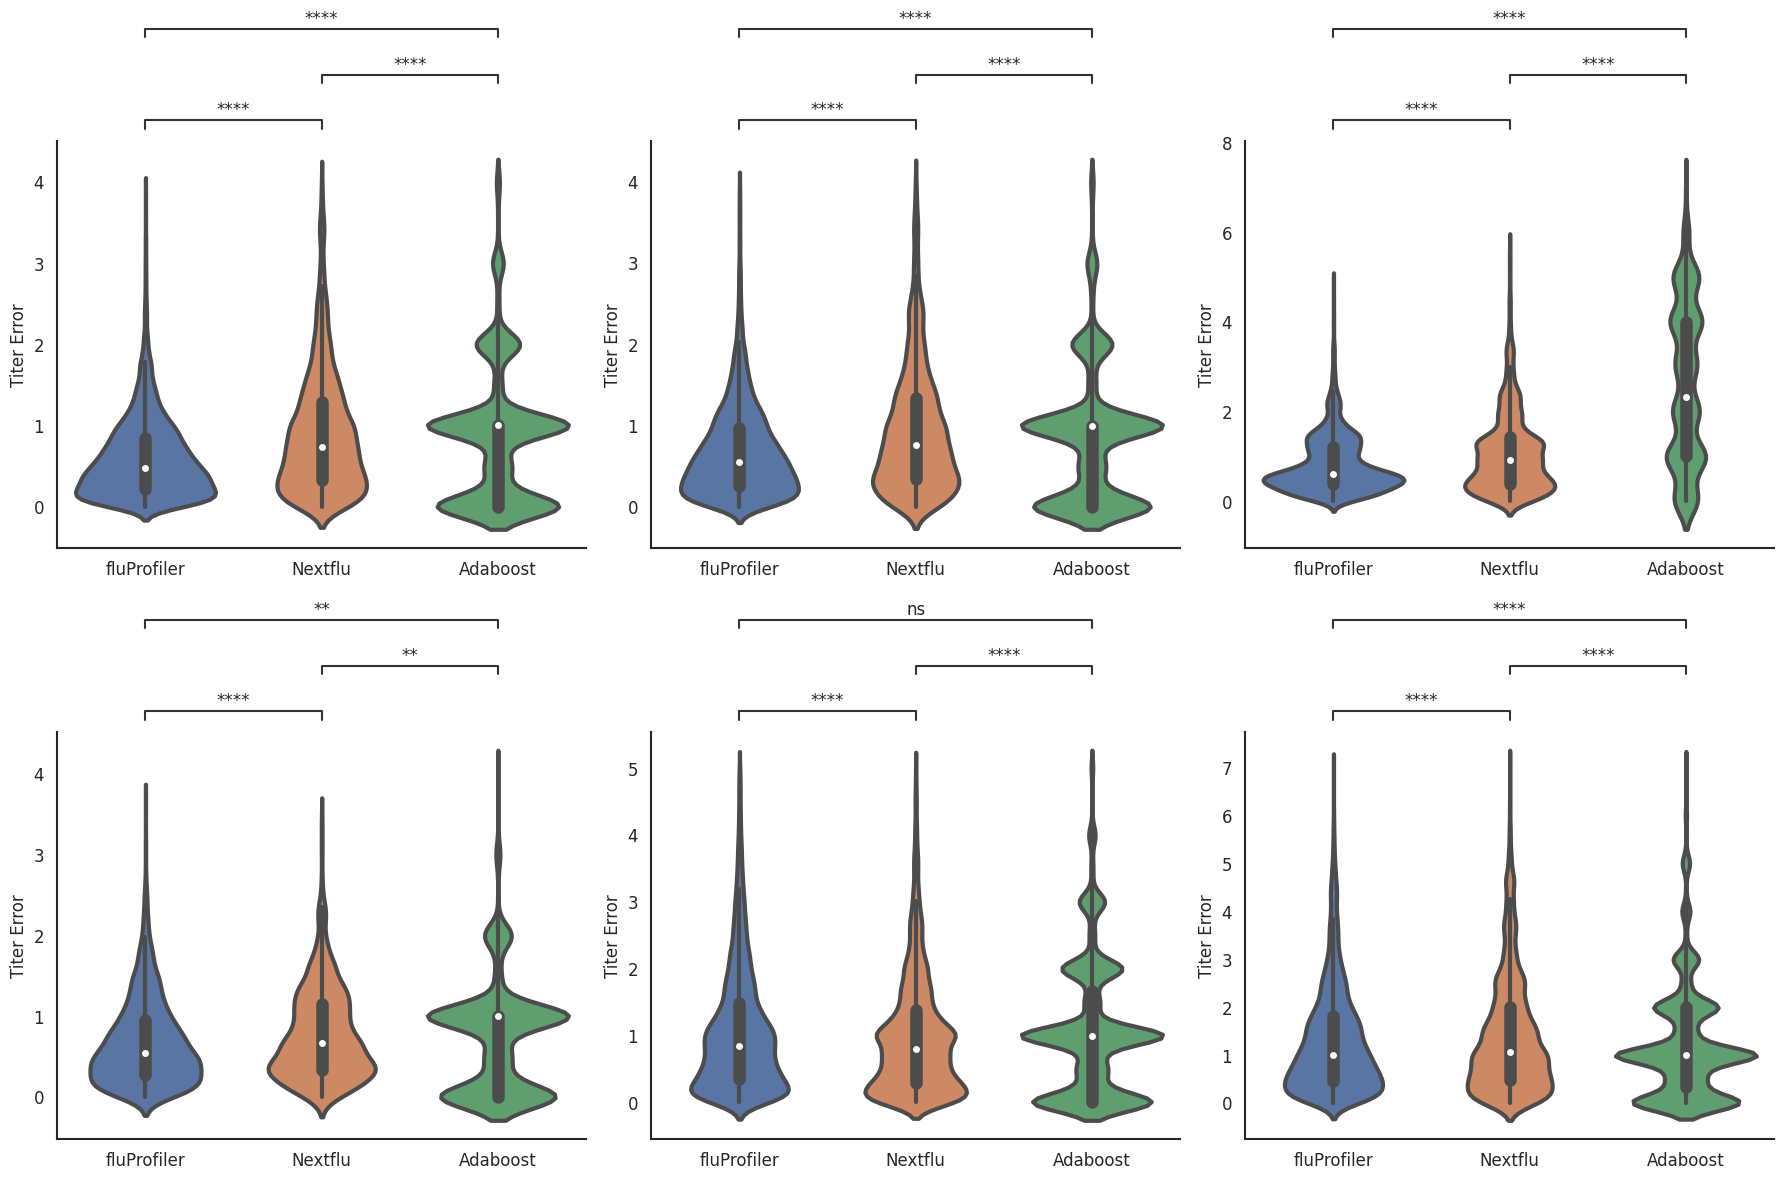

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from statannotations.Annotator import Annotator

sns.set(style='white')

# ====== 定义 pair（所有子图相同） ======
pairs = [
    ("fluProfiler", "Nextflu"),
    ("fluProfiler", "Adaboost"),
    ("Nextflu", "Adaboost"),
]

# ====== 限制极端值 ======
df_titer = to_concat_df(fluProfiler_titer_error, Nextflu_titer_error, Adaboost_titer_error)
df_strain = to_concat_df(fluProfiler_strain_error, Nextflu_strain_error, Adaboost_strain_error)
df_serum = to_concat_df(fluProfiler_serum_error, Nextflu_serum_error, Adaboost_serum_error)
df_41 = to_concat_df(fluProfiler_41_error, Nextflu_41_error, Adaboost_41_error)
df_CDC = to_concat_df(fluProfiler_CDC_error, Nextflu_CDC_error, Adaboost_CDC_error)
df_CNIC = to_concat_df(fluProfiler_CNIC_error, Nextflu_CNIC_error, Adaboost_CNIC_error)

df_titer = df_titer[df_titer['value'] <= 4]
df_strain = df_strain[df_strain['value'] <= 4]
df_serum = df_serum[df_serum['value'] <= 8]
df_41 = df_41[df_41['value'] <= 4]
df_CDC = df_CDC[df_CDC['value'] <= 5]
df_CNIC = df_CNIC[df_CNIC['value'] <= 7]

# ====== 创建子图 ======
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ====== 每个子图绘制 violin 并加显著性 ======
datasets = [
    (df_titer, axes[0,0], 'divided by titer'),
    (df_strain, axes[0,1], 'divided by strain'),
    (df_serum, axes[0,2], 'divided by serum'),
    (df_41, axes[1,0], '2024NH'),
    (df_CDC, axes[1,1], 'CDC'),
    (df_CNIC, axes[1,2], 'CNIC')
]

for df, ax, title in datasets:
    sns.violinplot(x='model', y='value', data=df, inner="box", linewidth=3, dodge=True, ax=ax)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    ax.set_ylabel('Titer Error', fontsize=12)
    ax.set_xlabel('')
    # ax.set_title(title, fontsize=14)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # 添加显著性标注
    annotator = Annotator(ax, pairs, data=df, x="model", y="value")
    annotator.configure(test='t-test_ind', text_format='star', loc='outside', verbose=0)
    annotator.apply_and_annotate()

plt.tight_layout()
plt.show()


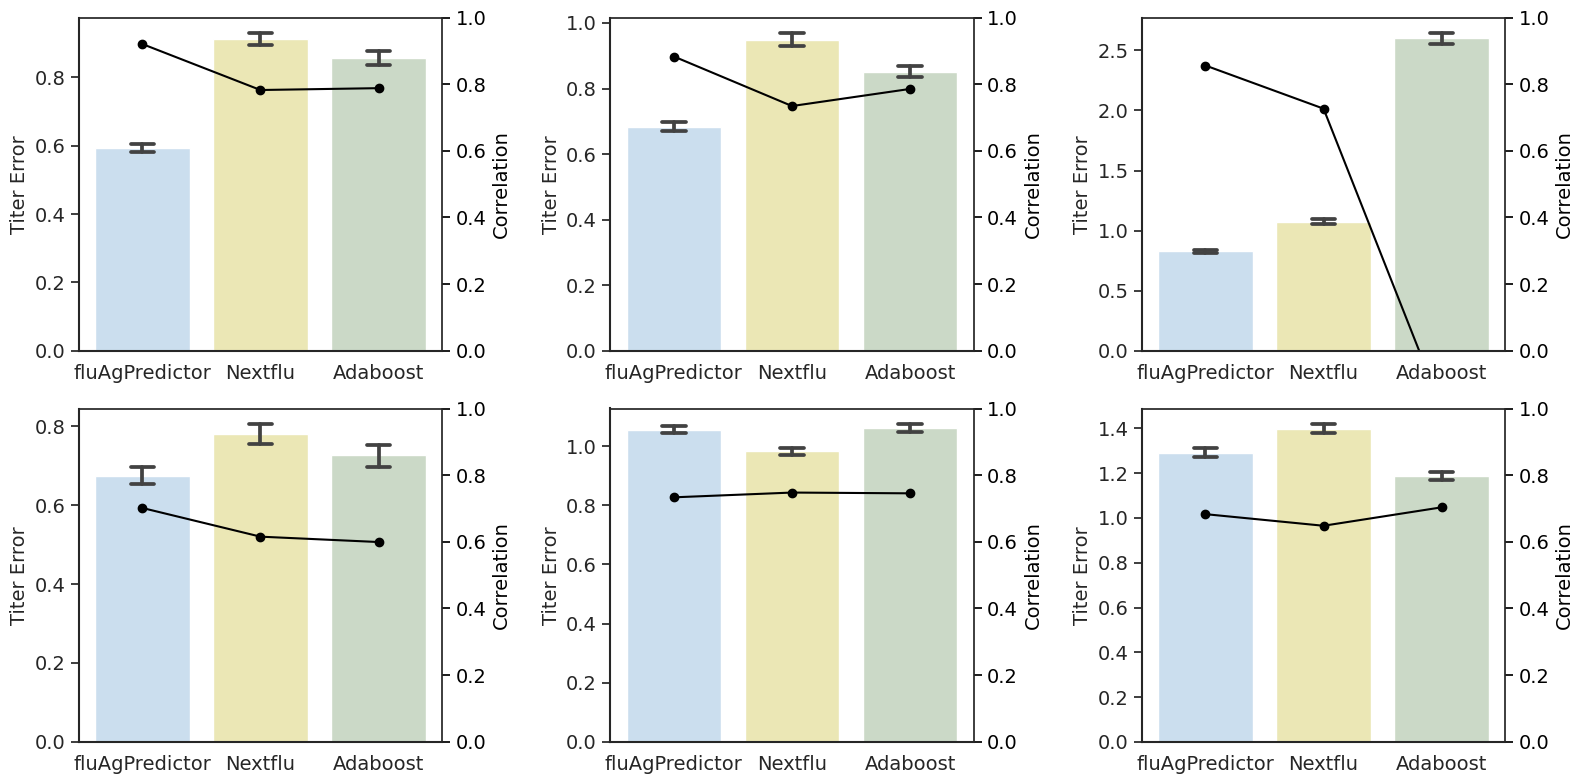

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statannotations.Annotator import Annotator
from scipy.stats import pearsonr

sns.set(style='white')

pairs = [
    ("fluProfiler", "Nextflu"),
    ("fluProfiler", "Adaboost"),
    ("Nextflu", "Adaboost"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

datasets = [
    (df_titer, axes[0,0], 'divided by titer', "titer"),
    (df_strain, axes[0,1], 'divided by strain', "strain"),
    (df_serum, axes[0,2], 'divided by serum', "serum"),
    (df_41, axes[1,0], '2024NH', "nh"),
    (df_CDC, axes[1,1], 'CDC', "cdc"),
    (df_CNIC, axes[1,2], 'CNIC', "cnic")
]

# 每个子图的相关性（长度=3）
correlations = {
    "titer":  [pearsonr(fluProfiler_titer['label'], fluProfiler_titer['prediction'])[0], 
    pearsonr(Nextflu_titer['label'], Nextflu_titer['pred_without_name'])[0], 
    pearsonr(Adaboost_titer['label'], Adaboost_titer['pred_without_name'])[0]],
    "strain": [pearsonr(fluProfiler_strain['label'], fluProfiler_strain['prediction'])[0], 
    pearsonr(Nextflu_strain['label'], Nextflu_strain['pred_without_name'])[0], 
    pearsonr(Adaboost_strain['label'], Adaboost_strain['pred_without_name'])[0]],
    "serum": [pearsonr(fluProfiler_serum['label'], fluProfiler_serum['prediction'])[0], 
    pearsonr(Nextflu_serum['label'], Nextflu_serum['pred_without_name'])[0], 
    pearsonr(Adaboost_serum['label'], Adaboost_serum['pred_without_name'])[0]],
    "nh": [pearsonr(fluProfiler_41['label'], fluProfiler_41['prediction'])[0], 
    pearsonr(Nextflu_41['label'], Nextflu_41['pred_without_name'])[0], 
    pearsonr(Adaboost_41['label'], Adaboost_41['pred_without_name'])[0]],
    "cdc": [pearsonr(fluProfiler_CDC['label'], fluProfiler_CDC['prediction'])[0], 
    pearsonr(Nextflu_CDC['label'], Nextflu_CDC['pred_without_name'])[0], 
    pearsonr(Adaboost_CDC['label'], Adaboost_CDC['pred_without_name'])[0]],
    "cnic": [pearsonr(fluProfiler_CNIC['label'], fluProfiler_CNIC['prediction'])[0], 
    pearsonr(Nextflu_CNIC['label'], Nextflu_CNIC['pred_without_name'])[0], 
    pearsonr(Adaboost_CNIC['label'], Adaboost_CNIC['pred_without_name'])[0]],
}

fixed_colors = ["#C5DFF4", "#F4EEAC", "#C9DCC4"]

for df, ax, title, key in datasets:
    sns.barplot(
        x='model',
        y='value',
        data=df,
        estimator=np.mean,
        errorbar='ci',
        capsize=0.2,
        ax=ax,
        palette=fixed_colors   # ← 指定固定三色
    )

    # 格式美化
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.set_ylabel('Titer Error', fontsize=14)
    ax.set_xlabel('')
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # 右轴相关性曲线
    corr_list = correlations[key]
    ax2 = ax.twinx()
    ax2.plot(range(len(corr_list)), corr_list, color='black', marker='o', linestyle='-')
    ax2.set_ylabel("Correlation", fontsize=14, color='black')
    ax2.tick_params(axis='y', labelsize=14, colors='black')
    ax2.set_ylim(0, 1)
    ax2.set_xticks(range(len(corr_list)))
    xticklabels = [m.replace('fluProfiler', 'fluAgPredictor') for m in df['model'].unique()]
    ax2.set_xticklabels(xticklabels)
    ax.set_xticklabels(xticklabels)

plt.tight_layout()
plt.savefig('Figure2.svg', dpi=300)

In [12]:
correlations

{'titer': [0.9203587765055674, 0.7824545642921472, 0.7880020065290758],
 'strain': [0.8829548056579636, 0.7343565613746514, 0.7857220283144943],
 'serum': [0.8559611033301767, 0.726506077345159, -0.17027516956458477],
 'nh': [0.7015197330377316, 0.6154851776059442, 0.5993795078743038],
 'cdc': [0.7335192478814709, 0.7478034434883629, 0.7454865455169484],
 'cnic': [0.6830019310077111, 0.648185851900819, 0.7034910664707823]}

In [19]:
tb = datasets[3][0]

In [20]:
print('fluProfiler:',tb.loc[tb['model'] == 'fluProfiler', 'value'].mean())
print('Nextflu:', tb.loc[tb['model'] == 'Nextflu', 'value'].mean())
print('Adaboost:', tb.loc[tb['model'] == 'Adaboost', 'value'].mean())

fluProfiler: 0.6745428731988736
Nextflu: 0.7794445545889647
Adaboost: 0.7262542629582412


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

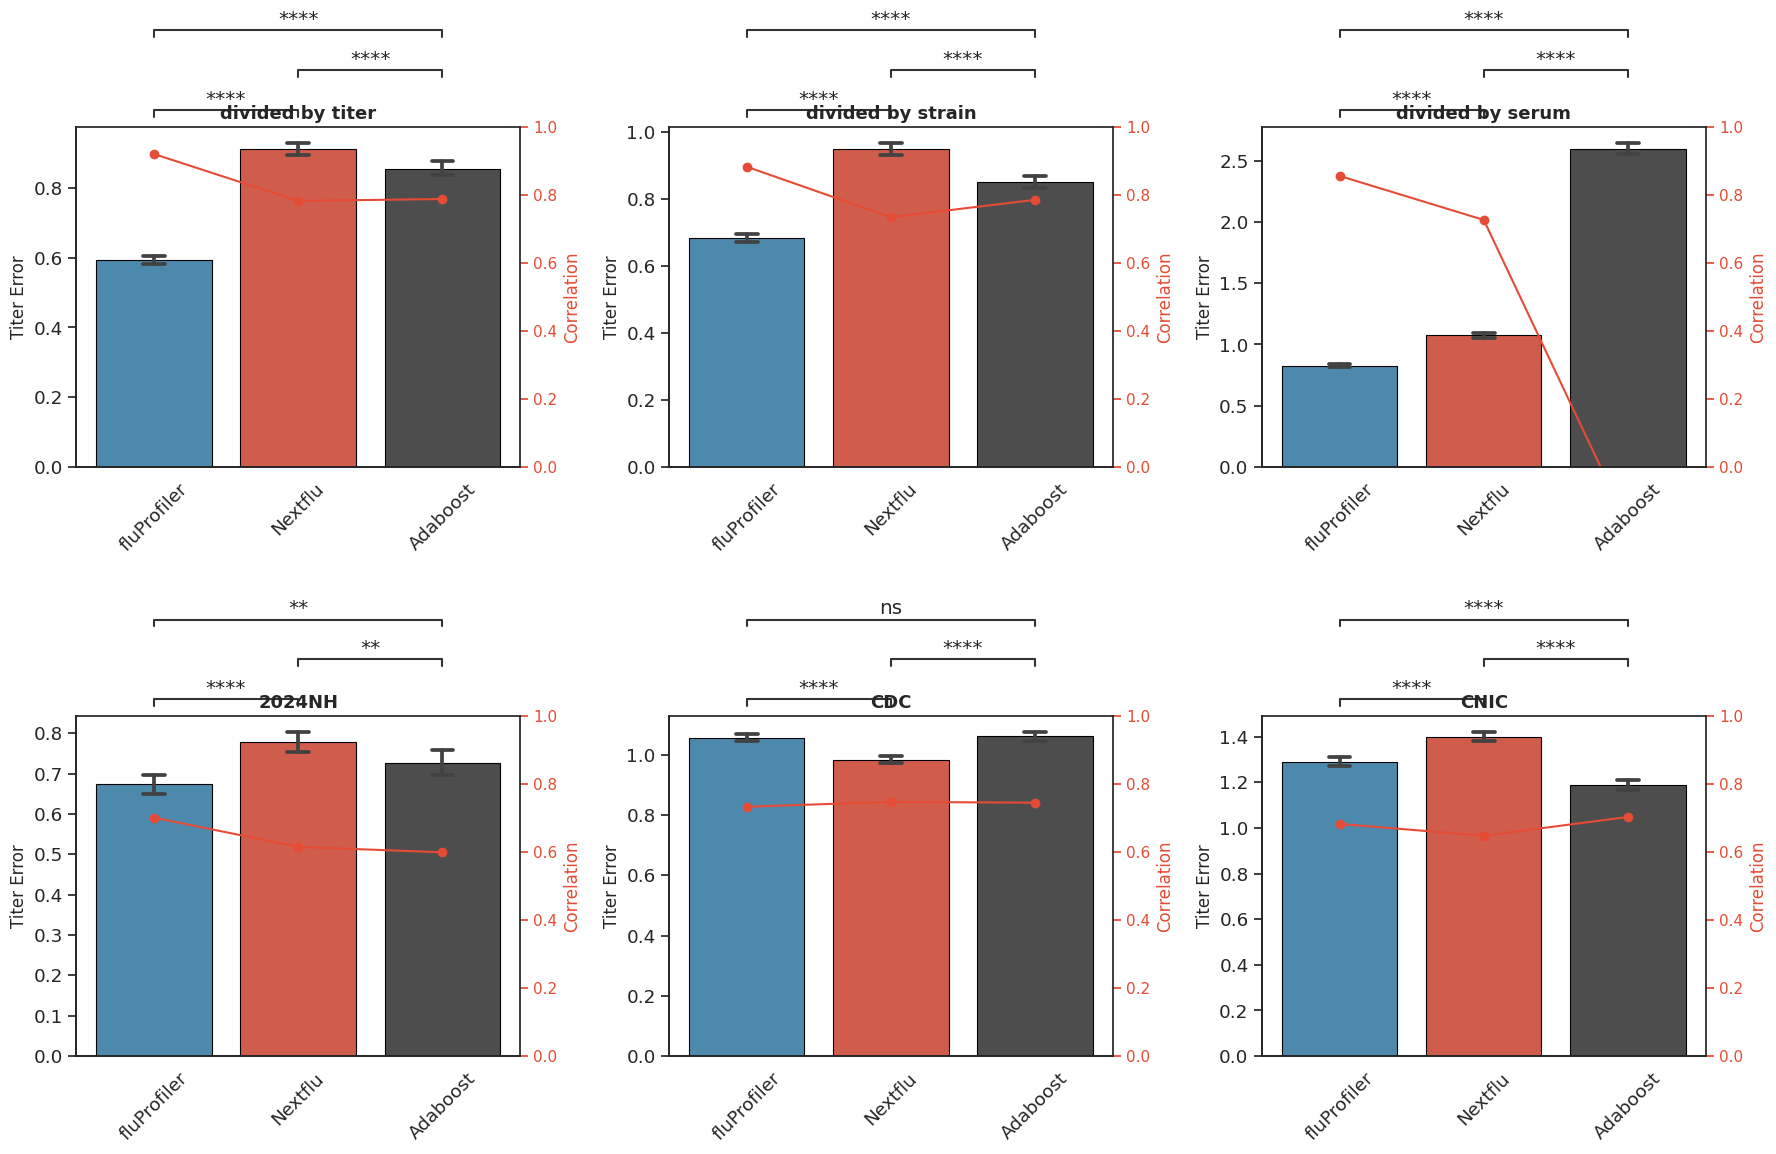

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statannotations.Annotator import Annotator
from scipy.stats import pearsonr

sns.set(style='white', font='Arial', font_scale=1.2)

# 统一色板（蓝、橙、灰）
palette = {
    'fluProfiler': '#3C8DBC',   # 蓝（主色）
    'Nextflu': '#E64B35',       # 橙（对比）
    'Adaboost': '#4D4D4D'       # 灰（中性）
}

pairs = [
    ("fluProfiler", "Nextflu"),
    ("fluProfiler", "Adaboost"),
    ("Nextflu", "Adaboost"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

datasets = [
    (df_titer, axes[0,0], 'divided by titer', "titer"),
    (df_strain, axes[0,1], 'divided by strain', "strain"),
    (df_serum, axes[0,2], 'divided by serum', "serum"),
    (df_41, axes[1,0], '2024NH', "nh"),
    (df_CDC, axes[1,1], 'CDC', "cdc"),
    (df_CNIC, axes[1,2], 'CNIC', "cnic")
]

for df, ax, title, key in datasets:
    sns.barplot(
        x='model', y='value', data=df,
        estimator=np.mean, errorbar='ci', capsize=0.15,
        palette=palette, ax=ax, edgecolor='black', linewidth=0.8
    )

    # 轴与网格格式
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Titer Error', fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    for spine in ['top', 'right']:import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statannotations.Annotator import Annotator
from scipy.stats import pearsonr

# ========== 图形基础风格 ==========
sns.set(style='white', font='Arial', font_scale=1.2)
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['pdf.fonttype'] = 42  # 确保矢量输出兼容AI

# ========== 降饱和Nature配色 ==========
palette = {

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

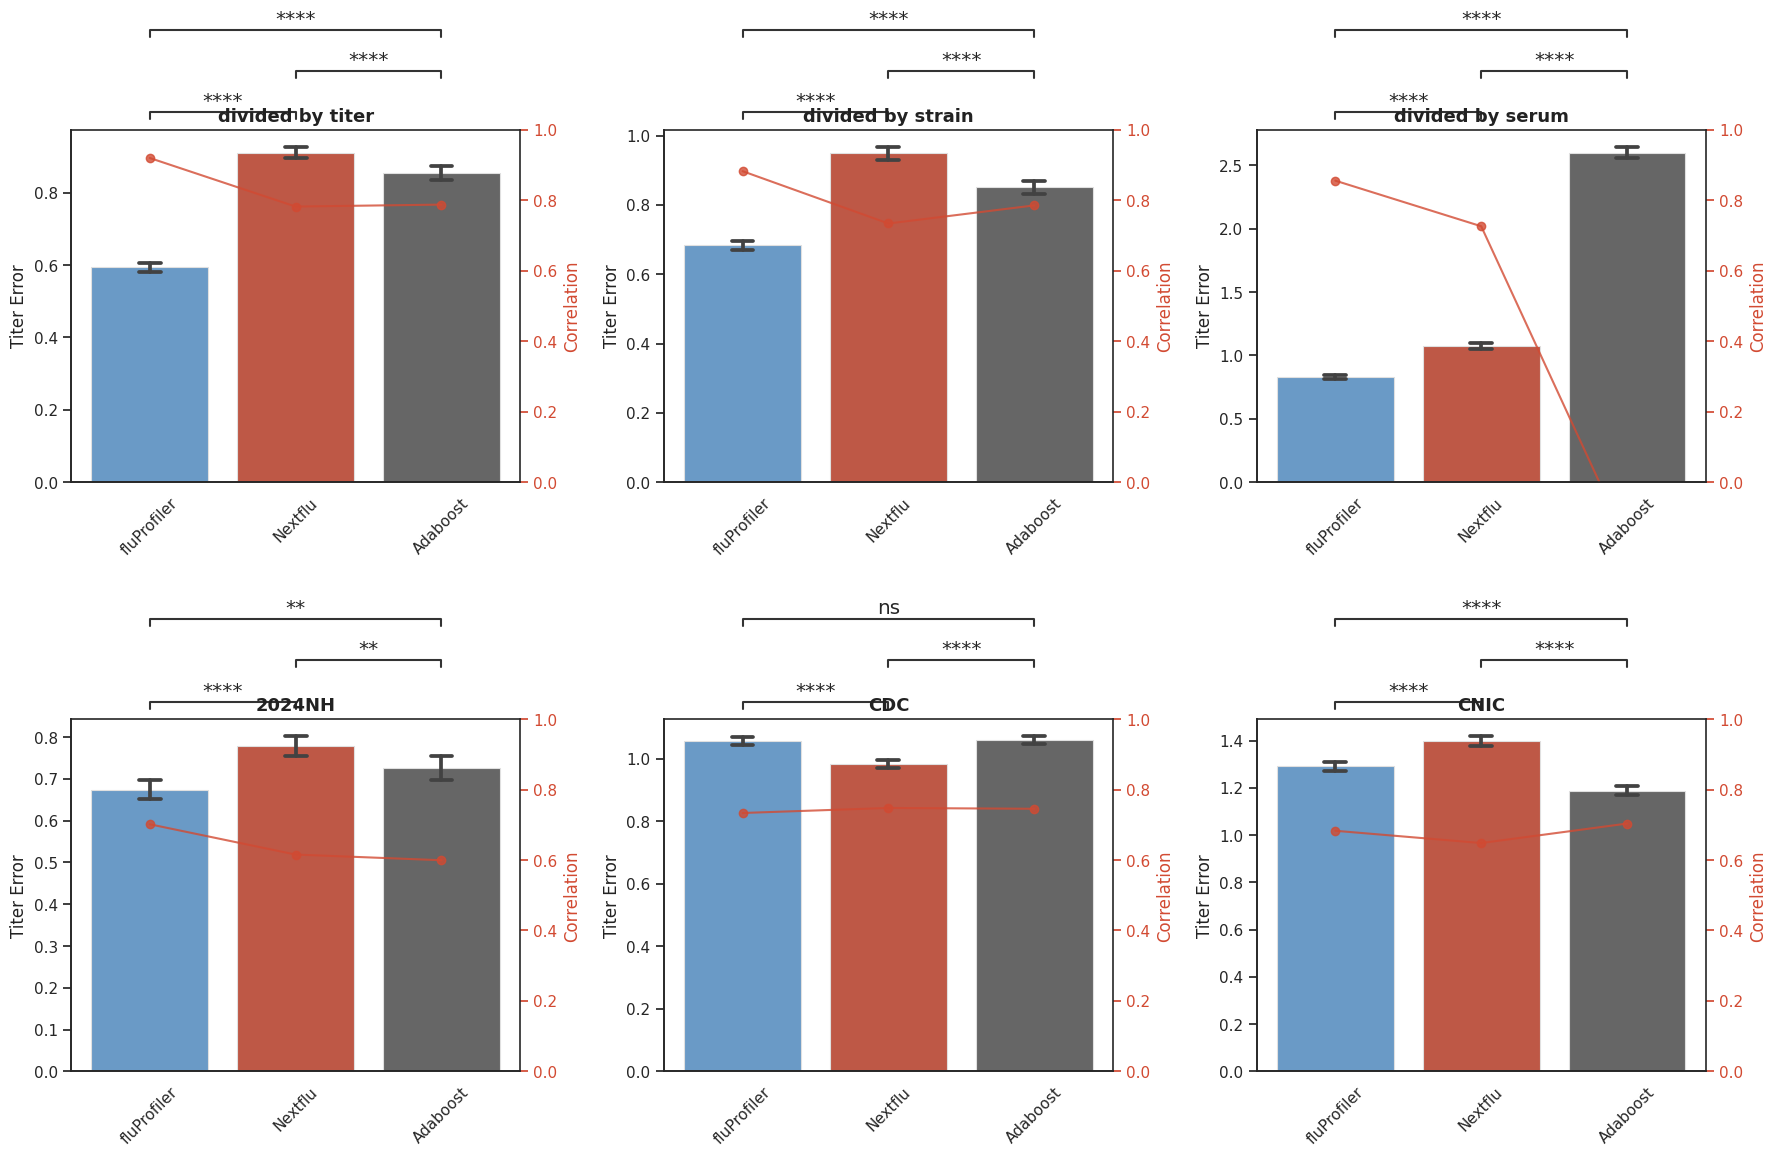

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statannotations.Annotator import Annotator
from scipy.stats import pearsonr

# ========== 图形基础风格 ==========
sns.set(style='white', font='Arial', font_scale=1.2)
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['pdf.fonttype'] = 42  # 确保矢量输出兼容AI

# ========== 降饱和Nature配色 ==========
palette = {
    'fluProfiler': '#5B9BD5',  # 柔和蓝
    'Nextflu': '#D24A32',      # 柔和橙
    'Adaboost': '#666666'      # 中性灰
}

# ========== 对比组 ==========
pairs = [
    ("fluProfiler", "Nextflu"),
    ("fluProfiler", "Adaboost"),
    ("Nextflu", "Adaboost"),
]

# ========== 画布布局 ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

datasets = [
    (df_titer,  axes[0,0], 'divided by titer', "titer"),
    (df_strain, axes[0,1], 'divided by strain', "strain"),
    (df_serum,  axes[0,2], 'divided by serum', "serum"),
    (df_41,     axes[1,0], '2024NH', "nh"),
    (df_CDC,    axes[1,1], 'CDC', "cdc"),
    (df_CNIC,   axes[1,2], 'CNIC', "cnic")
]

# ========== 相关性字典（示例保持不变） ==========
correlations = {
    "titer":  [pearsonr(fluProfiler_titer['label'], fluProfiler_titer['prediction'])[0], 
               pearsonr(Nextflu_titer['label'], Nextflu_titer['pred_without_name'])[0], 
               pearsonr(Adaboost_titer['label'], Adaboost_titer['pred_without_name'])[0]],
    "strain": [pearsonr(fluProfiler_strain['label'], fluProfiler_strain['prediction'])[0], 
               pearsonr(Nextflu_strain['label'], Nextflu_strain['pred_without_name'])[0], 
               pearsonr(Adaboost_strain['label'], Adaboost_strain['pred_without_name'])[0]],
    "serum":  [pearsonr(fluProfiler_serum['label'], fluProfiler_serum['prediction'])[0], 
               pearsonr(Nextflu_serum['label'], Nextflu_serum['pred_without_name'])[0], 
               pearsonr(Adaboost_serum['label'], Adaboost_serum['pred_without_name'])[0]],
    "nh":     [pearsonr(fluProfiler_41['label'], fluProfiler_41['prediction'])[0], 
               pearsonr(Nextflu_41['label'], Nextflu_41['pred_without_name'])[0], 
               pearsonr(Adaboost_41['label'], Adaboost_41['pred_without_name'])[0]],
    "cdc":    [pearsonr(fluProfiler_CDC['label'], fluProfiler_CDC['prediction'])[0], 
               pearsonr(Nextflu_CDC['label'], Nextflu_CDC['pred_without_name'])[0], 
               pearsonr(Adaboost_CDC['label'], Adaboost_CDC['pred_without_name'])[0]],
    "cnic":   [pearsonr(fluProfiler_CNIC['label'], fluProfiler_CNIC['prediction'])[0], 
               pearsonr(Nextflu_CNIC['label'], Nextflu_CNIC['pred_without_name'])[0], 
               pearsonr(Adaboost_CNIC['label'], Adaboost_CNIC['pred_without_name'])[0]],
}

# ========== 绘制主图 ==========
for df, ax, title, key in datasets:
    sns.barplot(
        x='model', y='value', data=df,
        estimator=np.mean, errorbar='ci', capsize=0.15,
        palette=palette, ax=ax,
        edgecolor='#E0E0E0', linewidth=0.8
    )

    # 轴样式
    ax.set_title(title, fontsize=13, fontweight='bold', color='#222222')
    ax.set_ylabel('Titer Error', fontsize=12, color='#222222')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # 显著性标注
    annotator = Annotator(ax, pairs, data=df, x="model", y="value")
    annotator.configure(test='t-test_ind', text_format='star', loc='outside', verbose=0)
    annotator.apply_and_annotate()

    # 右轴：相关性曲线
    corr_list = correlations[key]
    ax2 = ax.twinx()
    ax2.plot(
        range(len(corr_list)), corr_list,
        color='#D24A32', alpha=0.8,
        marker='o', markersize=6, linewidth=1.5
    )
    ax2.set_ylabel("Correlation", fontsize=12, color='#D24A32')
    ax2.tick_params(axis='y', labelsize=11, colors='#D24A32')
    ax2.set_ylim(0, 1)
    ax2.set_xticks(range(len(corr_list)))
    ax2.set_xticklabels(df['model'].unique())

plt.tight_layout()
plt.savefig('Figure2_NatureSoft.svg', dpi=600, bbox_inches='tight')
plt.show()


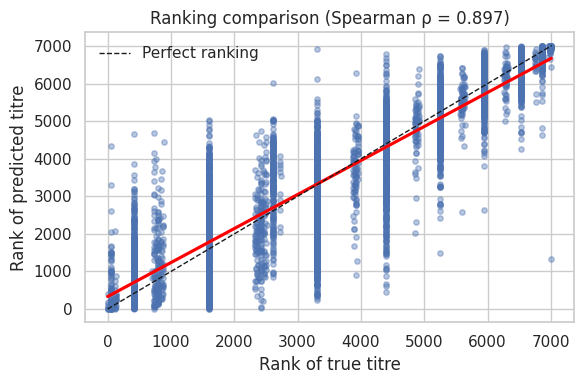

In [85]:
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
sns.set_style("whitegrid")

# 1. 计算秩（无 jitter）
rk_true  = fluProfiler_titer['label'].rank(method='average')
rk_pred  = fluProfiler_titer['prediction'].rank(method='average')

plt.figure(figsize=(6,4))
# 2. 用 regplot 画秩-秩关系
sns.regplot(x=rk_true, y=rk_pred,
            scatter_kws={'alpha':0.4, 's':15},
            line_kws={'color':'red'})
# 3. 对角参考线
plt.plot([0, len(rk_true)], [0, len(rk_true)], 'k--', lw=1, label='Perfect ranking')

plt.xlabel('Rank of true titre')
plt.ylabel('Rank of predicted titre')
plt.title('Ranking comparison (Spearman ρ = {:.3f})'.format(
          np.corrcoef(rk_true, rk_pred)[0,1]))
plt.legend()
plt.tight_layout()
plt.show()

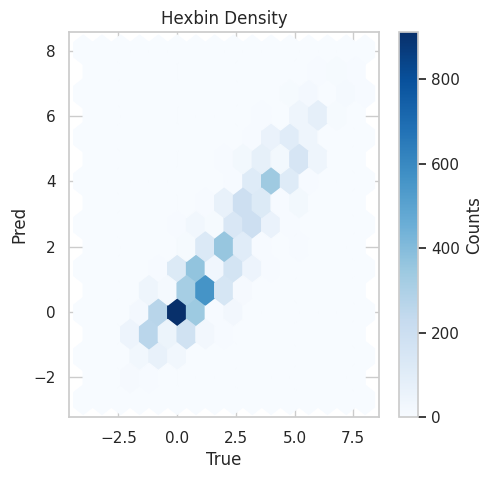

In [81]:
plt.figure(figsize=(5,5))
plt.hexbin(x, y, gridsize=15, cmap='Blues')
plt.colorbar(label='Counts')
plt.xlabel('True') ; plt.ylabel('Pred')
plt.title('Hexbin Density')
plt.show()